In [4]:
import math
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Union, Tuple, Optional
import matplotlib.pyplot as plt

In [70]:
RV_FILE = ("LSTM BIC.csv")
RF_FILE = "Risk-free Rate.csv"  

RV_COLUMNS = {
    "date": "B", 
    "real": "C", 
    "pred": "D",   
}
RF_COLUMNS = {
    "date": "A",     
    "rf":   "B",         
}

UNITS_MODE = "vol" 

SR = 0.4 # Sharpe
C  = 2.0 # Risk aversion
EPS = 1e-15 

SAVE_SERIES_CSV = False
SERIES_CSV_PATH = "ru_series.csv"

In [71]:
def col_letter_to_index(selector: Union[str, int]) -> Union[int, str]:
    if isinstance(selector, int):
        return selector
    if not isinstance(selector, str):
        return selector
    s = selector.strip()
    if len(s) == 1 and s.isalpha():
        # Excel letter to 0-based index
        return ord(s.upper()) - ord('A')
    return s  # assume it's a column name

def load_any_csv(path: Union[str, Path]) -> pd.DataFrame:
    path = Path(path)
    try:
        df = pd.read_csv(path)
        return df
    except Exception:
        df = pd.read_csv(path, header=None)
        return df

def pick_columns(df: pd.DataFrame, selectors: dict, rename_map: dict) -> pd.DataFrame:
    resolved = {}
    for out_name, sel in selectors.items():
        idx_or_name = col_letter_to_index(sel)
        if isinstance(idx_or_name, int):
            resolved[out_name] = df.iloc[:, idx_or_name]
        else:
            if idx_or_name not in df.columns:
                raise KeyError(f"Column '{idx_or_name}' not found in {list(df.columns)}")
            resolved[out_name] = df[idx_or_name]
    out = pd.DataFrame(resolved)
    out = out.rename(columns=rename_map)
    return out

def parse_dates(df: pd.DataFrame, date_col: str = "date") -> pd.DataFrame:
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)
    df = df.dropna(subset=[date_col])
    return df

def clean_rf_units(rf: pd.Series) -> pd.Series:
    x = pd.to_numeric(rf, errors="coerce")
    med = np.nanmedian(x)
    if np.isfinite(med) and med > 0.5:
        x = x / 100.0
    return x

def infer_units(series: pd.Series) -> str:
    s = pd.to_numeric(series, errors="coerce")
    if (s < 0).any():
        return "logvar"
    med = float(np.nanmedian(s))
    if med <= 0.02:
        return "var"
    elif med <= 0.5:
        return "vol"
    else:
        return "vol"

def to_variance(x: pd.Series, units: str) -> pd.Series:
    x = pd.to_numeric(x, errors="coerce").clip(lower=0)
    if units == "logvar":
        return np.exp(x)
    elif units == "var":
        return x
    elif units == "vol":
        return x**2
    else:
        return x

def realized_utility(real_vals: pd.Series, pred_vals: pd.Series, units: str, SR: float, C: float, EPS: float) -> pd.Series:
    real_var = to_variance(real_vals, units).clip(lower=EPS)
    pred_var = to_variance(pred_vals, units).clip(lower=EPS)
    ratio = real_var / pred_var
    return (SR**2 / C) * np.sqrt(ratio) - (SR**2 / (2*C)) * ratio

In [72]:
rv_raw = load_any_csv(RV_FILE)

rv_df = pick_columns(
    rv_raw,
    selectors={"date": RV_COLUMNS["date"], "real": RV_COLUMNS["real"], "pred": RV_COLUMNS["pred"]},
    rename_map={"date": "date", "real": "real", "pred": "pred"}
)
rv_df = parse_dates(rv_df, "date").sort_values("date").reset_index(drop=True)
rv_df["real"] = pd.to_numeric(rv_df["real"], errors="coerce")
rv_df["pred"] = pd.to_numeric(rv_df["pred"], errors="coerce")
rv_df = rv_df.dropna(subset=["real", "pred"])

rf_raw = load_any_csv(RF_FILE)
rf_df = pick_columns(
    rf_raw,
    selectors={"date": RF_COLUMNS["date"], "rf": RF_COLUMNS["rf"]},
    rename_map={"date": "date", "rf": "rf"}
)
rf_df = parse_dates(rf_df, "date").sort_values("date").reset_index(drop=True)
rf_df["rf"] = clean_rf_units(rf_df["rf"])

# Quick sanity checks
display(rv_df.head(3))
display(rf_df.head(3))
print(f"RV rows: {len(rv_df):,} | RF rows: {len(rf_df):,}")


/var/folders/kh/kpfdcx4n2x72jd3j7mc_fht40000gn/T/ipykernel_11014/595634188.py:37: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)
/var/folders/kh/kpfdcx4n2x72jd3j7mc_fht40000gn/T/ipykernel_11014/595634188.py:37: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)


,date,real,pred
0,2002-03-08,0.126973,0.153091
1,2002-03-11,0.103157,0.142961
2,2002-03-12,0.122952,0.130538


,date,rf
0,2002-01-02,0.0001
1,2002-01-03,0.0001
2,2002-01-04,0.0001


RV rows: 5,762 | RF rows: 5,869


In [73]:
#Align by earliest common date
min_rv_date = rv_df["date"].min()
min_rf_date = rf_df["date"].min()
start_date = max(min_rv_date, min_rf_date)

aligned = (
    rv_df.loc[rv_df["date"] >= start_date, ["date","real","pred"]]
          .merge(rf_df.loc[rf_df["date"] >= start_date, ["date","rf"]], on="date", how="inner")
          .sort_values("date")
          .reset_index(drop=True)
)

print(f"Earliest common start date: {start_date.date()}")
print(f"Aligned rows: {len(aligned):,}")
display(aligned.head(5))

Earliest common start date: 2002-03-08
Aligned rows: 5,762


,date,real,pred,rf
0,2002-03-08,0.126973,0.153091,0.0001
1,2002-03-11,0.103157,0.142961,0.0001
2,2002-03-12,0.122952,0.130538,0.0001
3,2002-03-13,0.128694,0.131976,0.0001
4,2002-03-14,0.099028,0.133150,0.0001


In [74]:
#Units
if UNITS_MODE == "auto":
    units = infer_units(aligned["real"])
else:
    units = UNITS_MODE

print(f"Units mode: {units!r} (UNITS_MODE={UNITS_MODE!r})")

ru_t = realized_utility(aligned["real"], aligned["pred"], units=units, SR=SR, C=C, EPS=EPS)
aligned = aligned.assign(RU_t=ru_t, RU_t_pct=100.0*ru_t)

RU_mean_pct = float(aligned["RU_t_pct"].mean())
RU_theoretical_pct = float((SR**2 / (2*C)) * 100.0)

print(f"Average Realized Utility: {RU_mean_pct:.6f}%")
print(f"Theoretical upper bound (perfect model): {RU_theoretical_pct:.6f}%")

Units mode: 'vol' (UNITS_MODE='vol')
Average Realized Utility: 3.731782%
Theoretical upper bound (perfect model): 4.000000%


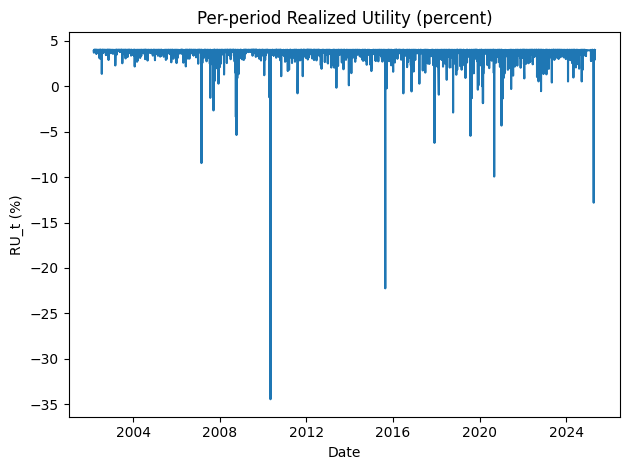

In [75]:
3.#Plot
plt.figure()
plt.plot(aligned["date"], aligned["RU_t_pct"])
plt.title("Per-period Realized Utility (percent)")
plt.xlabel("Date")
plt.ylabel("RU_t (%)")
plt.tight_layout()
plt.show()

In [76]:
#Save results
if SAVE_SERIES_CSV:
    pd.DataFrame({"date": aligned["date"], "RU_t": aligned["RU_t"], "RU_t_pct": aligned["RU_t_pct"]}).to_csv(SERIES_CSV_PATH, index=False)
    print(f"Saved RU series to: {SERIES_CSV_PATH}")